# ALS Collaborative Filtering (Warm-start focused)

## Goal

- Train a personalized recommender using Collaborative Filtering (ALS).

- Evaluate mainly on warm users (users with enough history in train)

# Load interactions (from Postgres)

In [1]:
import pandas as pd
import psycopg
from src.db.conn import get_db_conninfo


conninfo = get_db_conninfo()
print(conninfo)
with psycopg.connect(conninfo) as conn:
    df = pd.read_sql(
        "SELECT user_id, item_id, ts FROM interactions WHERE event_type='purchase';",
        conn,
    )

df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
df = (
    df.dropna(subset=["user_id", "item_id", "ts"])
    .drop_duplicates(subset=["user_id", "item_id", "ts"])
    .sort_values("ts")
    .reset_index(drop=True)
)

print(df.shape)
df.head()

host=localhost port=5432 dbname=olist_db user=postgres password=ADMIN01111709


C:\Users\Jesus\AppData\Local\Temp\ipykernel_19448\3832592129.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


(100165, 3)


,user_id,item_id,ts
0,830d5b7aaa3b6f1e9ad63703bec97d23,5a6b04657a4c5ee34285d1e4619a96b4,2016-09-15 12:16:38+00:00
1,32ea3bdedab835c3aa6cb68ce66565ef,3ae08df6bcbfe23586dd431c40bddbb7,2016-10-03 09:44:50+00:00
2,2f64e403852e6893ae37485d5fcacdaf,fd7fd78fd3cbc1b0a6370a7909c0a629,2016-10-03 16:56:50+00:00
3,61db744d2f835035a5625b59350c6b63,b72b39418216e944bb34e35f4d3ea8c7,2016-10-03 21:13:36+00:00
4,8d3a54507421dbd2ce0a1d58046826e0,107177bf61755f05c604fe57e02467d6,2016-10-03 22:06:03+00:00


# Import and Paths

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"

ORDERS_PATH = RAW_DIR / "olist_orders_dataset.csv"
ITEMS_PATH = RAW_DIR / "olist_order_items_dataset.csv"
CUSTOMERS_PATH = RAW_DIR / "olist_customers_dataset.csv"
REVIEWS_PATH = RAW_DIR / "olist_order_reviews_dataset.csv"
PRODUCTS_PATH = RAW_DIR / "olist_products_dataset.csv"
TRANSLATE_PATH = RAW_DIR / "product_category_name_translation.csv"

# Temporal split (train_df / test_df)

In [3]:
cut = df["ts"].quantile(0.80)
train_df = df[df["ts"] <= cut].copy()
test_df = df[df["ts"] > cut].copy()

print("cut:", cut)
print("train:", train_df.shape, "test:", test_df.shape)

cut: 2018-05-26 19:37:32+00:00
train: (80132, 3) test: (20033, 3)


In [4]:
# Interactions per user in TRAIN
train_user_counts = train_df.groupby("user_id").size()

print("TRAIN users:", train_user_counts.shape[0])
print("TRAIN interactions (events):", int(train_user_counts.sum()))
print("Avg interactions per user (train):", float(train_user_counts.mean()))
print("Median interactions per user (train):", float(train_user_counts.median()))

print("\nPercentiles:")
for p in [0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"  p{int(p * 100):02d}: {float(train_user_counts.quantile(p))}")

print("\nUsers with >=k interactions in train:")
for k in [1, 2, 3, 5, 10]:
    n = int((train_user_counts >= k).sum())
    print(f"  >= {k}: {n} users ({n / train_user_counts.shape[0]:.1%})")

TRAIN users: 74736
TRAIN interactions (events): 80132
Avg interactions per user (train): 1.0722008135302934
Median interactions per user (train): 1.0

Percentiles:
  p50: 1.0
  p75: 1.0
  p90: 1.0
  p95: 2.0
  p99: 2.0

Users with >=k interactions in train:
  >= 1: 74736 users (100.0%)
  >= 2: 4469 users (6.0%)
  >= 3: 654 users (0.9%)
  >= 5: 50 users (0.1%)
  >= 10: 2 users (0.0%)


# Build mappings from TRAIN only (user2idx, item2idx, idx2item)

In [5]:
user2idx = {u: i for i, u in enumerate(train_df["user_id"].unique())}
item2idx = {it: j for j, it in enumerate(train_df["item_id"].unique())}

idx2user = {i: u for u, i in user2idx.items()}
idx2item = {j: it for it, j in item2idx.items()}

n_users = len(user2idx)
n_items = len(item2idx)

print("n_users:", n_users, "n_items:", n_items)

n_users: 74736 n_items: 26016


# Build X_user_item (CSR) from TRAIN (counts per user-item)

In [6]:
import numpy as np
from scipy.sparse import coo_matrix

train_ui = train_df.groupby(
    ["user_id", "item_id"], as_index=False
).size()  # 'size' = count

rows = train_ui["user_id"].map(user2idx).to_numpy()
cols = train_ui["item_id"].map(item2idx).to_numpy()
data = train_ui["size"].astype(np.float32).to_numpy()

X_user_item = coo_matrix((data, (rows, cols)), shape=(n_users, n_items)).tocsr()

print("X_user_item:", X_user_item.shape, "nnz:", X_user_item.nnz)

X_user_item: (74736, 26016) nnz: 79839


# Train ALS (works with implicit version: fit on users x items)

In [7]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(
    factors=64, regularization=0.05, iterations=20, random_state=42
)

model.fit(X_user_item)

print("model.user_factors:", model.user_factors.shape)  # (n_users, factors)
print("model.item_factors:", model.item_factors.shape)  # (n_items, factors)

assert model.user_factors.shape[0] == n_users
assert model.item_factors.shape[0] == n_items

c:\Users\Jesus\anaconda3\envs\olist_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Jesus\anaconda3\envs\olist_project\lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: Intel MKL BLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'MKL_NUM_THREADS=1' or by callng 'threadpoolctl.threadpool_limits(1, "blas")'. Having MKL use a threadpool can lead to severe performance issues
  check_blas_config()
100%|██████████| 20/20 [00:01<00:00, 13.51it/s]

model.user_factors: (74736, 64)
model.item_factors: (26016, 64)


# Build warm evaluation set (>=2 interactions in train) + truth + users_eval

In [8]:
min_train_interactions = 2

train_counts = train_df.groupby("user_id").size()
eligible_users = set(train_counts[train_counts >= min_train_interactions].index)

# warm test: user must be eligible AND items must exist in train (warm items)
test_warm = test_df[
    test_df["user_id"].isin(eligible_users)
    & test_df["user_id"].isin(user2idx)
    & test_df["item_id"].isin(item2idx)
].copy()

truth = {}
for u, grp in test_warm.groupby("user_id"):
    u_idx = user2idx[u]
    truth[u_idx] = set(item2idx[i] for i in grp["item_id"].values)

users_eval = list(truth.keys())

print("Eligible users (>=3 train):", len(eligible_users))
print("Eval users (eligible + has test):", len(users_eval))
print("Unique items in test_warm:", test_warm["item_id"].nunique())

if len(users_eval) == 0:
    raise ValueError("No users left after filtering. Try min_train_interactions=2.")

Eligible users (>=3 train): 4469
Eval users (eligible + has test): 42
Unique items in test_warm: 47


# Evaluate ALS HitRate@K (product_id-level)

In [9]:
import numpy as np


def hitrate_at_k(truth_set, rec_items):
    return 1 if truth_set.intersection(rec_items) else 0


Ks = [1, 3, 5, 10, 15, 20, 30]
als_hit_rates = []

for K in Ks:
    hits = []
    for u in users_eval:
        ids, scores = model.recommend(
            userid=u,
            user_items=X_user_item[u],
            N=K,
            filter_already_liked_items=True,
        )
        rec_items = list(ids)
        hits.append(hitrate_at_k(truth[u], rec_items))
    als_hit_rates.append(float(np.mean(hits)))

print("ALS product-level HitRate@K:", list(zip(Ks, als_hit_rates)))

ALS product-level HitRate@K: [(1, 0.0), (3, 0.0), (5, 0.0), (10, 0.0), (15, 0.023809523809523808), (20, 0.023809523809523808), (30, 0.047619047619047616)]


# Category-level evaluation + Category Popularity baseline

## Load product -> category

In [10]:
products = pd.read_csv(PRODUCTS_PATH)
translate = pd.read_csv(TRANSLATE_PATH)

products = products.merge(translate, on="product_category_name", how="left")
products["category"] = products["product_category_name_english"].fillna(
    products["product_category_name"]
)

prod2cat = products.set_index("product_id")["category"].to_dict()

## Add category columns

In [11]:
train_df_cat = train_df.copy()
test_df_cat = test_df.copy()
train_df_cat["category"] = train_df_cat["item_id"].map(prod2cat)
test_df_cat["category"] = test_df_cat["item_id"].map(prod2cat)
train_df_cat = train_df_cat.dropna(subset=["category"])
test_df_cat = test_df_cat.dropna(subset=["category"])

## eligible users >=2 in train

In [12]:
train_counts = train_df_cat.groupby("user_id").size()
eligible_users = set(train_counts[train_counts >= min_train_interactions].index)

test_warm_cat = test_df_cat[test_df_cat["user_id"].isin(eligible_users)].copy()

# truth at category-level (user_id keys, not idx)

In [13]:
truth_cat = test_warm_cat.groupby("user_id")["category"].apply(set).to_dict()
users_eval_cat = list(truth_cat.keys())
print("Eligible users (>=3 train):", len(eligible_users))
print("Eval users (eligible + has test):", len(users_eval_cat))

Eligible users (>=3 train): 4379
Eval users (eligible + has test): 63


# baseline: global category popularity from train

In [14]:
# Check unique categories in train and test
cats_test = sorted(test_df_cat["category"].dropna().unique())
print("Unique categories in TEST:", len(cats_test))

test_cat_counts = test_df_cat["category"].value_counts()
print("Top categories in TEST:\n", test_cat_counts.head(10))

cats_test[:30], cats_test[-10:]


Unique categories in TEST: 70
Top categories in TEST:
 category
health_beauty            2370
bed_bath_table           1941
housewares               1583
watches_gifts            1433
sports_leisure           1283
computers_accessories    1162
furniture_decor          1096
auto                      970
telephony                 687
baby                      656
Name: count, dtype: int64


(['agro_industry_and_commerce',
  'air_conditioning',
  'art',
  'arts_and_craftmanship',
  'audio',
  'auto',
  'baby',
  'bed_bath_table',
  'books_general_interest',
  'books_imported',
  'books_technical',
  'christmas_supplies',
  'cine_photo',
  'computers',
  'computers_accessories',
  'consoles_games',
  'construction_tools_construction',
  'construction_tools_lights',
  'construction_tools_safety',
  'cool_stuff',
  'costruction_tools_garden',
  'costruction_tools_tools',
  'diapers_and_hygiene',
  'drinks',
  'dvds_blu_ray',
  'electronics',
  'fashio_female_clothing',
  'fashion_bags_accessories',
  'fashion_childrens_clothes',
  'fashion_male_clothing'],
 ['portateis_cozinha_e_preparadores_de_alimentos',
  'signaling_and_security',
  'small_appliances',
  'small_appliances_home_oven_and_coffee',
  'sports_leisure',
  'stationery',
  'tablets_printing_image',
  'telephony',
  'toys',
  'watches_gifts'])

In [15]:
Ks = [1, 3, 5, 10, 15, 20]

top_cats = train_df_cat["category"].value_counts().index.tolist()


def hitrate_set(truth_set, rec_list):
    return 1 if truth_set.intersection(rec_list) else 0


# Category Popularity hitrate
pop_cat_hit = []
for K in Ks:
    rec_k = top_cats[:K]
    pop_cat_hit.append(
        float(np.mean([hitrate_set(truth_cat[u], rec_k) for u in users_eval_cat]))
    )

# ALS category hitrate

In [16]:
als_cat_hit = []
for K in Ks:
    hits = []
    for u_id in users_eval_cat:
        if u_id not in user2idx:
            continue
        u_idx = user2idx[u_id]

        ids, scores = model.recommend(
            userid=u_idx,
            user_items=X_user_item[u_idx],
            N=K,
            filter_already_liked_items=True,
        )
        rec_prod_ids = [idx2item[int(it_idx)] for it_idx in ids]
        rec_cats = [prod2cat.get(pid) for pid in rec_prod_ids]
        rec_cats = [c for c in rec_cats if c is not None]

        hits.append(hitrate_set(truth_cat[u_id], rec_cats))
    als_cat_hit.append(float(np.mean(hits)))

In [17]:
print("Category Popularity HitRate@K:", list(zip(Ks, pop_cat_hit)))
print("ALS (category) HitRate@K:", list(zip(Ks, als_cat_hit)))

Category Popularity HitRate@K: [(1, 0.2222222222222222), (3, 0.4444444444444444), (5, 0.5238095238095238), (10, 0.6825396825396826), (15, 0.7777777777777778), (20, 0.9365079365079365)]
ALS (category) HitRate@K: [(1, 0.047619047619047616), (3, 0.1746031746031746), (5, 0.23809523809523808), (10, 0.42857142857142855), (15, 0.5714285714285714), (20, 0.6825396825396826)]


# Plot ALS vs Popularity 

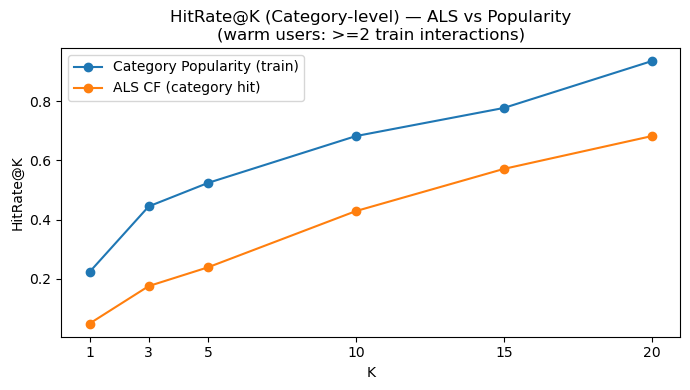

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(Ks, pop_cat_hit, marker="o", label="Category Popularity (train)")
plt.plot(Ks, als_cat_hit, marker="o", label="ALS CF (category hit)")
plt.title(
    "HitRate@K (Category-level) — ALS vs Popularity\n(warm users: >=2 train interactions)"
)
plt.xlabel("K")
plt.ylabel("HitRate@K")
plt.xticks(Ks)
plt.legend()
plt.tight_layout()
plt.show()